In [1]:
pwd

'C:\\Users\\acer'

In [2]:
cd C:\Users\acer\Downloads\dataset

C:\Users\acer\Downloads\dataset


In [3]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect('data.db')

# Query to select all data from a table (replace 'your_table' with the actual table name)
query_train = 'SELECT * FROM TRAIN;'
query_test = 'SELECT * FROM TEST;'

# Use pandas to read the query result into a DataFrame
df_train = pd.read_sql_query(query_train, conn)
df_test = pd.read_sql_query(query_test, conn)

# Close the database connection
conn.close()

# Now, 'df' contains the data from the specified table in the SQLite database


In [4]:
df_train

,ID,Customer_Type,Customer_Age,Source_location_type,Destination_location_type,Distance,Peak,Traffic,Time,Weather,Is_weekend,Customer_demand,Price
0,0x2cd1,New,14.0,Inside_City,Outside_City,7.6,No,48.6,Morning,Sunny,No,7.36,6.84
1,0x10985,New,25.0,Outside_City,Inside_City,8.1,Yes,85.8,Midday,Sunny,No,6.42,8.71
2,0xae8d,New,19.0,Inside_City,Inside_City,13.1,No,86.0,Morning,Sunny,Yes,NaN,10.16
3,0x86ab,Regular,46.0,Inside_City,Inside_City,4.7,No,67.1,Midnight,Windy,No,6.19,13.44
4,0x8c,Inactive,52.0,Inside_City,Outside_City,2.6,No,39.8,Midday,Rainy,No,5.83,11.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57197,0x3779,New,29.0,Inside_City,Outside_City,7.9,No,####,Evening,Rainy,No,4.06,10.32
57198,0x666b,Passive,24.0,Outside_City,Outside_City,27.3,Yes,34.1,Night,Sunny,No,NaN,17.77
57199,0xcce,New,32.0,Inside_City,Outside_City,8.6,Yes,53.0,Midday,Windy,No,6.23,7.85
57200,0x3d49,Passive,29.0,Inside_City,Outside_City,11.5,Yes,45.7,Night,Rainy,Yes,4.89,13.88


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57202 entries, 0 to 57201
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         57202 non-null  object 
 1   Customer_Type              57202 non-null  object 
 2   Customer_Age               55725 non-null  float64
 3   Source_location_type       57202 non-null  object 
 4   Destination_location_type  57202 non-null  object 
 5   Distance                   54789 non-null  float64
 6   Peak                       57202 non-null  object 
 7   Traffic                    57202 non-null  object 
 8   Time                       57202 non-null  object 
 9   Weather                    57202 non-null  object 
 10  Is_weekend                 57202 non-null  object 
 11  Customer_demand            52040 non-null  float64
 12  Price                      57202 non-null  float64
dtypes: float64(4), object(9)
memory usage: 5.7+ MB

In [6]:
df_train.shape

(57202, 13)

In [7]:
df_test.shape

(12472, 12)

In [8]:
df_train.isna().sum()

ID                              0
Customer_Type                   0
Customer_Age                 1477
Source_location_type            0
Destination_location_type       0
Distance                     2413
Peak                            0
Traffic                         0
Time                            0
Weather                         0
Is_weekend                      0
Customer_demand              5162
Price                           0
dtype: int64

In [9]:
df_test.isna().sum()

ID                              0
Customer_Type                   0
Customer_Age                  317
Source_location_type            0
Destination_location_type       0
Distance                      494
Peak                            0
Traffic                         0
Time                            0
Weather                         0
Is_weekend                      0
Customer_demand              1113
dtype: int64

In [10]:
from scipy.stats import shapiro

def norm_test(data):
    # Assuming 'data' is your sample data
    stat, p_value = shapiro(data)

    print(f'Shapiro-Wilk Test: Statistics={stat}, p-value={p_value}')

    # Interpret the result
    alpha = 0.05
    if p_value > alpha:
        print("Sample looks Gaussian (fail to reject H0)")
    else:
        print("Sample does not look Gaussian (reject H0)")


In [11]:
norm_test(df_train["Customer_Age"])

Shapiro-Wilk Test: Statistics=nan, p-value=1.0
Sample looks Gaussian (fail to reject H0)


C:\Users\acer\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [12]:
norm_test(df_train["Distance"])    

Shapiro-Wilk Test: Statistics=nan, p-value=1.0
Sample looks Gaussian (fail to reject H0)


In [13]:
df_train["Traffic"] = pd.to_numeric(df_train["Traffic"], errors='coerce')

In [14]:
norm_test(df_train["Traffic"])    

Shapiro-Wilk Test: Statistics=nan, p-value=1.0
Sample looks Gaussian (fail to reject H0)


In [15]:
norm_test(df_train["Customer_demand"])    

Shapiro-Wilk Test: Statistics=nan, p-value=1.0
Sample looks Gaussian (fail to reject H0)


In [16]:
norm_test(df_train["Price"])    

Shapiro-Wilk Test: Statistics=0.9665520787239075, p-value=0.0
Sample does not look Gaussian (reject H0)


In [17]:
df_train

,ID,Customer_Type,Customer_Age,Source_location_type,Destination_location_type,Distance,Peak,Traffic,Time,Weather,Is_weekend,Customer_demand,Price
0,0x2cd1,New,14.0,Inside_City,Outside_City,7.6,No,48.6,Morning,Sunny,No,7.36,6.84
1,0x10985,New,25.0,Outside_City,Inside_City,8.1,Yes,85.8,Midday,Sunny,No,6.42,8.71
2,0xae8d,New,19.0,Inside_City,Inside_City,13.1,No,86.0,Morning,Sunny,Yes,NaN,10.16
3,0x86ab,Regular,46.0,Inside_City,Inside_City,4.7,No,67.1,Midnight,Windy,No,6.19,13.44
4,0x8c,Inactive,52.0,Inside_City,Outside_City,2.6,No,39.8,Midday,Rainy,No,5.83,11.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57197,0x3779,New,29.0,Inside_City,Outside_City,7.9,No,NaN,Evening,Rainy,No,4.06,10.32
57198,0x666b,Passive,24.0,Outside_City,Outside_City,27.3,Yes,34.1,Night,Sunny,No,NaN,17.77
57199,0xcce,New,32.0,Inside_City,Outside_City,8.6,Yes,53.0,Midday,Windy,No,6.23,7.85
57200,0x3d49,Passive,29.0,Inside_City,Outside_City,11.5,Yes,45.7,Night,Rainy,Yes,4.89,13.88


In [18]:
df_train["Customer_Type"].value_counts()

Customer_Type
New          22590
Passive      16789
Regular      11268
Inactive      5705
#R%$G&867      850
Name: count, dtype: int64

In [19]:
df_train["Source_location_type"].value_counts()

Source_location_type
Inside_City     36987
Outside_City    20215
Name: count, dtype: int64

In [20]:
df_train["Destination_location_type"].value_counts()

Destination_location_type
Outside_City    31538
Inside_City     25664
Name: count, dtype: int64

In [21]:
df_train["Peak"].value_counts()

Peak
No         41368
Yes        13841
unknown     1993
Name: count, dtype: int64

In [22]:
df_train["Time"].value_counts()

Time
Morning     17368
Evening     15893
Midday      10768
Night        9552
Midnight     3621
Name: count, dtype: int64

In [23]:
df_train["Weather"].value_counts()

Weather
Sunny     18947
Windy     17169
Cloudy    12144
Rainy      5840
Stormy     3102
Name: count, dtype: int64

In [24]:
df_train["Is_weekend"].value_counts()

Is_weekend
No     49803
Yes     7399
Name: count, dtype: int64

In [25]:
X = df_train.drop(['ID','Price'],axis=1)
Y = df_train['Price']

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

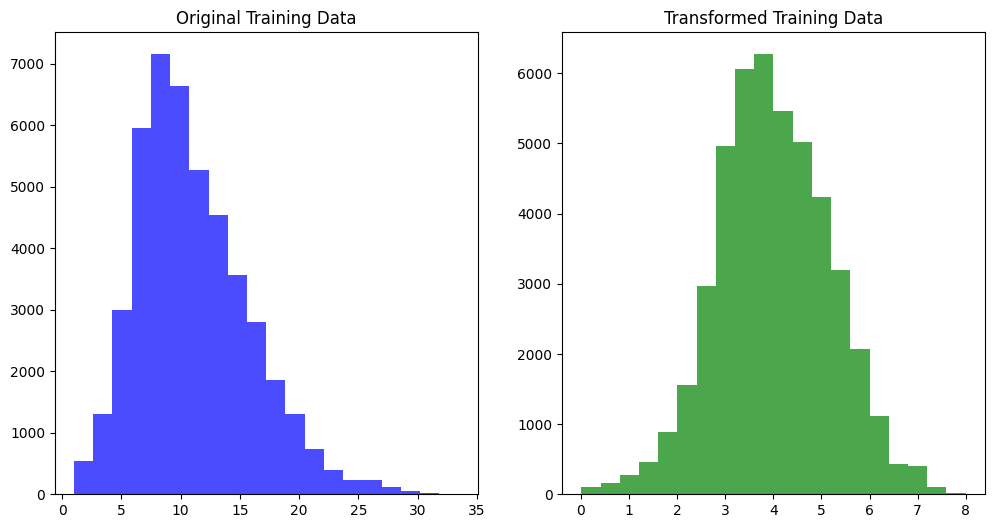

Text(0.5, 1.0, 'Transformed Test Data')

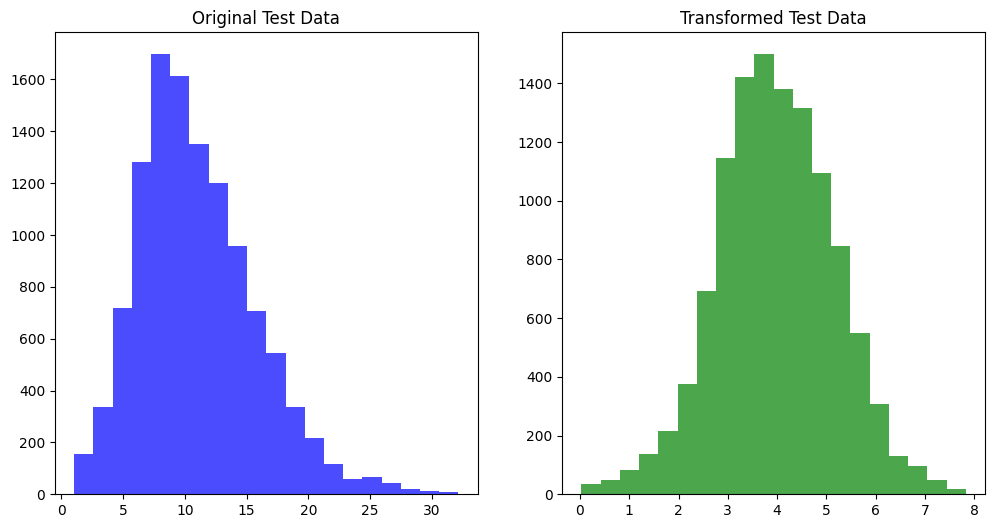

In [27]:
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt

# Applying PowerTransformer to both training and test data
power_transformer = PowerTransformer(method='box-cox', standardize=False)
transformed_y_train = power_transformer.fit_transform(y_train.values.reshape(-1, 1))
transformed_y_test = power_transformer.transform(y_test.values.reshape(-1, 1))

# Plotting the original and transformed training data
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=20, color='blue', alpha=0.7)
plt.title('Original Training Data')

plt.subplot(1, 2, 2)
plt.hist(transformed_y_train, bins=20, color='green', alpha=0.7)
plt.title('Transformed Training Data')

plt.show()

# Plotting the original and transformed test data
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(y_test, bins=20, color='blue', alpha=0.7)
plt.title('Original Test Data')

plt.subplot(1, 2, 2)
plt.hist(transformed_y_test, bins=20, color='green', alpha=0.7)
plt.title('Transformed Test Data')

In [28]:
from sklearn.impute import SimpleImputer
# Assuming 'df_train' and 'df_test' are your train and test DataFrames
imputer1 = SimpleImputer(strategy='median')  # Use mean, median, or most_frequent
X_train["Customer_Age"] = imputer1.fit_transform(X_train["Customer_Age"].values.reshape(-1, 1))
X_test["Customer_Age"] = imputer1.transform(X_test["Customer_Age"].values.reshape(-1, 1))

In [29]:
imputer2 = SimpleImputer(strategy='median')  # Use mean, median, or most_frequent
X_train["Distance"] = imputer2.fit_transform(X_train["Distance"].values.reshape(-1, 1))
X_test["Distance"] = imputer2.transform(X_test["Distance"].values.reshape(-1, 1))

In [30]:
imputer3 = SimpleImputer(strategy='median')  # Use mean, median, or most_frequent
X_train["Customer_demand"] = imputer3.fit_transform(X_train["Customer_demand"].values.reshape(-1, 1))
X_test["Customer_demand"] = imputer3.transform(X_test["Customer_demand"].values.reshape(-1, 1))

In [31]:
imputer4 = SimpleImputer(strategy='median')  # Use mean, median, or most_frequent
X_train["Traffic"] = imputer4.fit_transform(X_train["Traffic"].values.reshape(-1, 1))
X_test["Traffic"] = imputer4.transform(X_test["Traffic"].values.reshape(-1, 1))

In [32]:
from sklearn.preprocessing import OneHotEncoder
enc1 = OneHotEncoder(handle_unknown='ignore')
Customer_Type_tr = enc1.fit_transform(X_train["Customer_Type"].values.reshape(-1, 1) )
Customer_Type_test = enc1.transform(X_test["Customer_Type"].values.reshape(-1, 1) )

In [33]:
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
Customer_Age_tr = scaler1.fit_transform(X_train["Customer_Age"].values.reshape(-1, 1) )
Customer_Age_test = scaler1.transform(X_test["Customer_Age"].values.reshape(-1, 1) )

In [34]:
enc2 = OneHotEncoder(handle_unknown='ignore')
Source_location_type_tr = enc2.fit_transform(X_train["Source_location_type"].values.reshape(-1, 1) )
Source_location_type_test = enc2.transform(X_test["Source_location_type"].values.reshape(-1, 1) )

In [35]:
enc3 = OneHotEncoder(handle_unknown='ignore')
Destination_location_type_tr = enc3.fit_transform(X_train["Destination_location_type"].values.reshape(-1, 1) )
Destination_location_type_test = enc3.transform(X_test["Destination_location_type"].values.reshape(-1, 1) )

In [36]:
scaler2 = StandardScaler()
Distance_tr = scaler2.fit_transform(X_train["Distance"].values.reshape(-1, 1) )
Distance_test = scaler2.transform(X_test["Distance"].values.reshape(-1, 1) )

In [37]:
enc4 = OneHotEncoder(handle_unknown='ignore')
Peak_tr = enc4.fit_transform(X_train["Peak"].values.reshape(-1, 1) )
Peak_test = enc4.transform(X_test["Peak"].values.reshape(-1, 1) )

In [38]:
scaler3 = StandardScaler()
Traffic_tr = scaler3.fit_transform(X_train["Traffic"].values.reshape(-1, 1) )
Traffic_test = scaler3.transform(X_test["Traffic"].values.reshape(-1, 1) )

In [39]:
enc5 = OneHotEncoder(handle_unknown='ignore')
Time_tr = enc5.fit_transform(X_train["Time"].values.reshape(-1, 1) )
Time_test = enc5.transform(X_test["Time"].values.reshape(-1, 1) )

In [40]:
enc6 = OneHotEncoder(handle_unknown='ignore')
Weather_tr = enc6.fit_transform(X_train["Weather"].values.reshape(-1, 1) )
Weather_test = enc6.transform(X_test["Weather"].values.reshape(-1, 1) )

In [41]:
enc7 = OneHotEncoder(handle_unknown='ignore')
Is_weekend_tr = enc7.fit_transform(X_train["Is_weekend"].values.reshape(-1, 1) )
Is_weekend_test = enc7.transform(X_test["Is_weekend"].values.reshape(-1, 1) )

In [42]:
scaler4 = StandardScaler()
Customer_demand_tr = scaler4.fit_transform(X_train["Customer_demand"].values.reshape(-1, 1) )
Customer_demand_test = scaler4.transform(X_test["Customer_demand"].values.reshape(-1, 1) )

In [43]:
scaler5 = StandardScaler()
y_tr = scaler5.fit_transform(y_train.values.reshape(-1, 1) ).ravel()
y_test = scaler5.transform(y_test.values.reshape(-1, 1) ).ravel()

In [44]:
scaler6 = StandardScaler()
transformed_y_tr = scaler6.fit_transform(transformed_y_train.reshape(-1, 1) ).ravel()
transformed_y_test = scaler6.transform(transformed_y_test.reshape(-1, 1) ).ravel()

In [45]:
from scipy.sparse import hstack
# with the same hstack function we are concatinating a sparse matrix and a dense matirx :)
XTR = hstack((Customer_Type_tr, Customer_Age_tr, Source_location_type_tr, Destination_location_type_tr, Distance_tr, Peak_tr, Traffic_tr, Time_tr, Weather_tr,  Is_weekend_tr, Customer_demand_tr))
XTE = hstack((Customer_Type_test, Customer_Age_test, Source_location_type_test, Destination_location_type_test, Distance_test, Peak_test, Traffic_test, Time_test, Weather_test,  Is_weekend_test, Customer_demand_test))

In [135]:
%%time
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# SGD Regressor
sgd_model = SGDRegressor()

# Define the hyperparameter grid for SGD Regressor
param_grid_sgd = {
    'alpha': [0.000000001,0.00000001,0.0000001,0.000001,0.00001,0.0001, 0.001, 0.01,0.1,1,10,100],
    'max_iter': [1000, 2000, 5000,10000,20000,50000,100000],
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'eta0': [0.0001,0.001,0.01,1, 0.1, 0.5]
}

# Create GridSearchCV object with 'r2' as the scoring metric
grid_search_sgd = GridSearchCV(estimator=sgd_model, param_grid=param_grid_sgd, cv=5, scoring='r2',verbose=1)

# Fit the grid search to the data
grid_search_sgd.fit(XTR, y_tr)

# Display the best parameters and corresponding performance
print("SGD Regressor - Best Parameters: ", grid_search_sgd.best_params_)
print("SGD Regressor - Best R-squared: {:.2f}".format(grid_search_sgd.best_score_))

# Evaluate the model on the test set using the best parameters
sgd_train_predictions = grid_search_sgd.best_estimator_.predict(XTR)
r2_train = r2_score(y_tr, sgd_train_predictions)
print("\nTrain R-squared for SGD Regressor: {:.2f}".format(r2_train))

sgd_test_predictions = grid_search_sgd.best_estimator_.predict(XTE)
r2_test = r2_score(y_test, sgd_test_predictions)
print("\nTest R-squared for SGD Regressor: {:.2f}".format(r2_test))

Fitting 5 folds for each of 1512 candidates, totalling 7560 fits


C:\Users\acer\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGD Regressor - Best Parameters:  {'alpha': 1e-05, 'eta0': 0.0001, 'learning_rate': 'constant', 'max_iter': 10000}
SGD Regressor - Best R-squared: 0.55

Train R-squared for SGD Regressor: 0.55

Test R-squared for SGD Regressor: 0.54
CPU times: total: 14min 7s
Wall time: 28min 58s


In [136]:
# SGD Regressor with the best parameters
best_sgd_model = SGDRegressor(**grid_search_sgd.best_params_)

# Fit the model on the training data with the best parameters
best_sgd_model.fit(XTR, y_tr)

# Predict on the test data
sgd_train_predictions = best_sgd_model.predict(XTR)
sgd_test_predictions = best_sgd_model.predict(XTE)

# Evaluate the model on the test set using R-squared
r2_train = r2_score(y_tr, sgd_train_predictions)
print("Train R-squared for SGD Regressor with Best Parameters: {:.2f}".format(r2_train))

r2_test = r2_score(y_test, sgd_test_predictions)
print("Test R-squared for SGD Regressor with Best Parameters: {:.2f}".format(r2_test))

Train R-squared for SGD Regressor with Best Parameters: 0.55
Test R-squared for SGD Regressor with Best Parameters: 0.54


In [46]:
%%time
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor()

# Define the hyperparameters and their possible values for tuning
param_grid = {
    'bootstrap': [True, False],
    'max_features': ['auto', 'sqrt',2,4,6,8,10],
    'n_estimators': [20, 50, 100, 150,200],
    'max_depth': [None, 2,4,6,8,10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use GridSearchCV to find the best combination of hyperparameters
grid_search_rf = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, scoring='r2', cv=5)
grid_search_rf.fit(XTR, y_tr)

# Display the best parameters and corresponding performance
print("RF Regressor - Best Parameters: ", grid_search_rf.best_params_)
print("RF Regressor - Best R-squared: {:.2f}".format(grid_search_rf.best_score_))

# Evaluate the model on the test set using the best parameters
rf_train_predictions = grid_search_rf.best_estimator_.predict(XTR)
r2_train = r2_score(y_tr, rf_train_predictions)
print("\nTrain R-squared for SGD Regressor: {:.2f}".format(r2_train))

rf_test_predictions = grid_search_rf.best_estimator_.predict(XTE)
r2_test = r2_score(y_test, rf_test_predictions)
print("\nTest R-squared for SGD Regressor: {:.2f}".format(r2_test))

KeyboardInterrupt: 

In [47]:
# RF Regressor with the best parameters
best_rf_model = RandomForestRegressor(**grid_search_rf.best_params_)

# Fit the model on the training data with the best parameters
best_rf_model.fit(XTR, y_tr)

# Predict on the test data
rf_train_predictions = best_rf_model.predict(XTR)
rf_test_predictions = best_rf_model.predict(XTE)

# Evaluate the model on the test set using R-squared
r2_train = r2_score(y_tr, rf_train_predictions)
print("Train R-squared for RF Regressor with Best Parameters: {:.2f}".format(r2_train))

r2_test = r2_score(y_test, rf_test_predictions)
print("Test R-squared for RF Regressor with Best Parameters: {:.2f}".format(r2_test))

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [132]:
%%time
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# SGD Regressor
transformed_sgd_model = SGDRegressor()

# Define the hyperparameter grid for SGD Regressor
param_grid_sgd = {
    'alpha': [0.000000001,0.00000001,0.0000001,0.000001,0.00001,0.0001, 0.001, 0.01,0.1,1,10,100],
    'max_iter': [1000, 2000, 5000,10000,20000,50000,100000],
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'eta0': [0.0001,0.001,0.01,1, 0.1, 0.5]
}

# Create GridSearchCV object with 'r2' as the scoring metric
transformed_grid_search_sgd = GridSearchCV(estimator=transformed_sgd_model, param_grid=param_grid_sgd, cv=5, scoring='r2',verbose=1)

# Fit the grid search to the data
transformed_grid_search_sgd.fit(XTR, transformed_y_tr)

# Display the best parameters and corresponding performance
print("SGD Regressor - Best Parameters: ", transformed_grid_search_sgd.best_params_)
print("SGD Regressor - Best R-squared: {:.2f}".format(transformed_grid_search_sgd.best_score_))

# Evaluate the model on the test set using the best parameters
transformed_sgd_train_predictions = transformed_grid_search_sgd.best_estimator_.predict(XTR)
transformed_r2_train = r2_score(transformed_y_tr, transformed_sgd_train_predictions)
print("\nTrain R-squared for SGD Regressor: {:.2f}".format(transformed_r2_train))

transformed_sgd_test_predictions = transformed_grid_search_sgd.best_estimator_.predict(XTE)
transformed_r2_test = r2_score(transformed_y_test, transformed_sgd_test_predictions)
print("\nTest R-squared for SGD Regressor: {:.2f}".format(transformed_r2_test))

Fitting 5 folds for each of 1512 candidates, totalling 7560 fits
SGD Regressor - Best Parameters:  {'alpha': 0.0001, 'eta0': 0.0001, 'learning_rate': 'constant', 'max_iter': 100000}
SGD Regressor - Best R-squared: 0.55

Train R-squared for SGD Regressor: 0.55

Test R-squared for SGD Regressor: 0.54
CPU times: total: 12min 23s
Wall time: 12min 32s


In [134]:
# SGD Regressor with the best parameters
transformed_best_sgd_model = SGDRegressor(**transformed_grid_search_sgd.best_params_)

# Fit the model on the training data with the best parameters
transformed_best_sgd_model.fit(XTR, transformed_y_tr)

# Predict on the test data
transformed_sgd_train_predictions = transformed_best_sgd_model.predict(XTR)
transformed_sgd_test_predictions = transformed_best_sgd_model.predict(XTE)

# Evaluate the model on the test set using R-squared
transformed_r2_train = r2_score(transformed_y_tr, transformed_sgd_train_predictions)
print("Train R-squared for SGD Regressor with Best Parameters: {:.2f}".format(transformed_r2_train))

transformed_r2_test = r2_score(y_test, transformed_sgd_test_predictions)
print("Test R-squared for SGD Regressor with Best Parameters: {:.2f}".format(transformed_r2_test))

Train R-squared for SGD Regressor with Best Parameters: 0.55
Test R-squared for SGD Regressor with Best Parameters: 0.54


In [58]:
%%time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

transformed_rf_regressor = RandomForestRegressor()

# Define the hyperparameters and their possible values for tuning
param_grid = {
    'max_features': [2,4,6,8,10],
    'n_estimators': [10,20, 50, 100,200,500],
    'max_depth': [2,4,6,8,10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Use GridSearchCV to find the best combination of hyperparameters
transformed_grid_search_rf = GridSearchCV(estimator=transformed_rf_regressor, param_grid=param_grid, scoring='r2', cv=5,verbose=2,return_train_score=True)
transformed_grid_search_rf.fit(XTR, transformed_y_tr)

# Display the best parameters and corresponding performance
print("RF Regressor - Best Parameters: ", transformed_grid_search_rf.best_params_)
print("RF Regressor - Best R-squared: {:.2f}".format(transformed_grid_search_rf.best_score_))

# Evaluate the model on the test set using the best parameters
transformed_rf_train_predictions = transformed_grid_search_rf.best_estimator_.predict(XTR)
transformed_r2_train = r2_score(transformed_y_tr, transformed_rf_train_predictions)
print("\nTrain R-squared for SGD Regressor: {:.2f}".format(transformed_r2_train))

transformed_rf_test_predictions = transformed_grid_search_rf.best_estimator_.predict(XTE)
transformed_r2_test = r2_score(transformed_y_test, transformed_rf_test_predictions)
print("\nTest R-squared for SGD Regressor: {:.2f}".format(transformed_r2_test))

Fitting 5 folds for each of 1350 candidates, totalling 6750 fits
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=20; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=20; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=2, n_estimators=20; total time=   0.0s
[CV] END max_de

[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.2s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.2s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.2s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.5s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.5s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.5s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END max_depth=2, max_features=2, min_samples_leaf=1, min_sample

[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   1.6s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   1.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   1.1s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=   3.3s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=   2.9s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=   3.4s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=   3.1s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time=   2.9s
[CV] END max_depth=2, max_features=2, min_samples_leaf=2, min_samples_sp

[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=20; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=20; total time=   0.0s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END max_depth=2, max_features=2, min_samples_leaf=4, min_samples_split=5, n

[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.9s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_sp

[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   3.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   3.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   3.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=   3.7s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_sp

[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=20; total time=   0.0s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.4s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_split=10, n_estimators=50; total time=   0.3s
[CV] END max_depth=2, max_features=4, min_samples_leaf=2, min_samples_sp

KeyboardInterrupt: 

In [59]:
# RF Regressor with the best parameters
transformed_best_rf_model = RandomForestRegressor(**transformed_grid_search_rf.best_params_)

# Fit the model on the training data with the best parameters
transformed_best_rf_model.fit(XTR, transformed_y_tr)

# Predict on the test data
transformed_rf_train_predictions = transformed_best_rf_model.predict(XTR)
transformed_rf_test_predictions = transformed_best_rf_model.predict(XTE)

# Evaluate the model on the test set using R-squared
transformed_r2_train = r2_score(transformed_y_tr, transformed_rf_train_predictions)
print("Train R-squared for RF Regressor with Best Parameters: {:.2f}".format(r2_train))

transformed_r2_test = r2_score(transformed_y_test, transformed_rf_test_predictions)
print("Test R-squared for RF Regressor with Best Parameters: {:.2f}".format(transformed_r2_test))

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

# Predictions

In [ ]:
df_test["Traffic"] = pd.to_numeric(df_test["Traffic"], errors='coerce')
df_test["Customer_Age"] = imputer1.transform(df_test["Customer_Age"].values.reshape(-1, 1))
df_test["Distance"] = imputer2.transform(df_test["Distance"].values.reshape(-1, 1))
df_test["Customer_demand"] = imputer3.transform(df_test["Customer_demand"].values.reshape(-1, 1))
df_test["Traffic"] = imputer4.transform(df_test["Traffic"].values.reshape(-1, 1))
Customer_Type_Test = enc1.transform(df_test["Customer_Type"].values.reshape(-1, 1) )
Customer_Age_Test = scaler1.transform(df_test["Customer_Age"].values.reshape(-1, 1) )
Source_location_type_Test = enc2.transform(df_test["Source_location_type"].values.reshape(-1, 1) )
Destination_location_type_Test = enc3.transform(df_test["Destination_location_type"].values.reshape(-1, 1) )
Distance_Test = scaler2.transform(df_test["Distance"].values.reshape(-1, 1) )
Peak_Test = enc4.transform(df_test["Peak"].values.reshape(-1, 1) )
Traffic_Test = scaler3.transform(df_test["Traffic"].values.reshape(-1, 1) )
Time_Test = enc5.transform(df_test["Time"].values.reshape(-1, 1) )
Weather_Test = enc6.transform(df_test["Weather"].values.reshape(-1, 1) )
Is_weekend_Test = enc7.transform(df_test["Is_weekend"].values.reshape(-1, 1) )
Customer_demand_Test = scaler4.transform(df_test["Customer_demand"].values.reshape(-1, 1))

In [ ]:
XT = hstack((Customer_Type_Test, Customer_Age_Test, Source_location_type_Test, Destination_location_type_Test, Distance_Test, Peak_Test, Traffic_Test, Time_Test, Weather_Test,  Is_weekend_Test, Customer_demand_Test))

In [48]:
sgd_Test_predictions = best_sgd_model.predict(XT)

In [ ]:
sgd_Test_predictions = scaler6.inverse_transform(sgd_Test_predictions)

In [49]:
final_submission = pd.DataFrame({'ID': df_test["ID"], 'Price': sgd_Test_predictions})

In [50]:
final_submission

,ID,Price
0,0x108fd,0.295358
1,0xaa0f,1.063710
2,0x791d,-0.692163
3,0x149c,-0.265431
4,0x1a77,0.427335
...,...,...
12467,0xcaab,-0.072582
12468,0x10305,0.067119
12469,0xccb,-0.100305
12470,0x27cb,0.195630


In [51]:
final_submission.to_csv("final_submission.csv")